In [41]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt

In [42]:
np.sqrt(0.94019**2 + 0.931269**2)

np.float64(1.3233363844695725)

In [22]:
@nb.njit
def f_cut_off(r):
    R_1 = 1.7#e-10
    R_2 = 2.0#e-10
    if r < R_1:
        return 1
    elif R_1 < r < R_2:
        return (1/2)*(1+np.cos((r-R_1)/(R_2-R_1)*np.pi))
    elif r > R_2:
        return 0

In [23]:
@nb.njit
def V_R(r):
    D_e = 6.325
    S = 1.29
    beta = 1.5
    R_e = 1.315
    return f_cut_off(r)*(D_e/(S-1))*np.exp(-beta*np.sqrt(2*S)*(r-R_e))

@nb.njit
def V_A(r):
    D_e = 6.325
    S = 1.29
    beta = 1.5
    R_e = 1.315
    return f_cut_off(r)*(D_e*S/(S-1))*np.exp(-beta*np.sqrt(2/S)*(r-R_e))

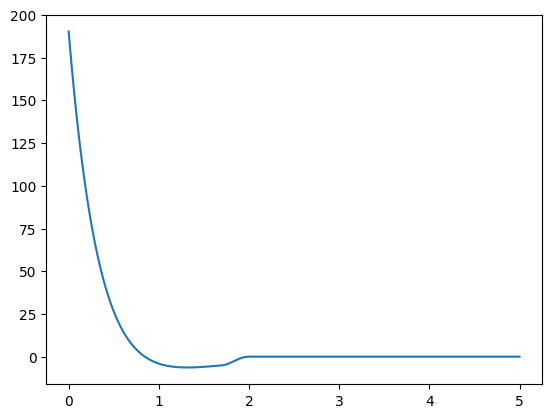

In [24]:
N = 100000
r = np.linspace(0,5, N)
r1 = np.linspace(1.5,2.4, N)
# r = np.linspace(0,20e-10, N)
ra = np.zeros((N), dtype=np.float64)
rv = np.zeros((N), dtype=np.float64)
cut_off = np.zeros((N), dtype=np.float64)
for i in range(N):
    rv[i] = V_R(r[i])
    ra[i] = V_A(r[i])
    cut_off[i] = f_cut_off(r1[i])
# plt.plot(r, ra)
# plt.plot(r, rv)

plt.plot(r, rv-ra)
plt.show()

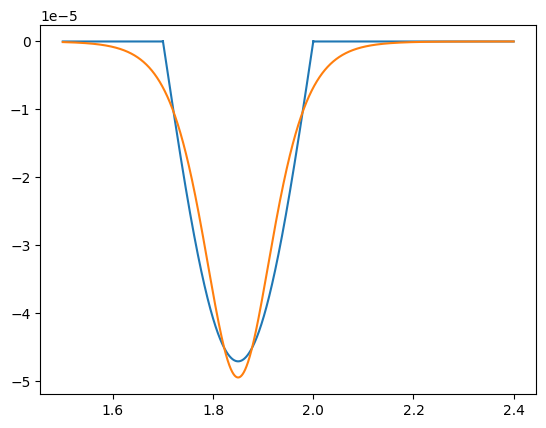

In [25]:
# plt.plot(r1, cut_off)
var = -22
# plt.plot(r1, np.exp(var*(r1-1.85)) / (1 + np.exp(var*(r1-1.85))))
plt.plot(r1[1:], np.diff(cut_off))
plt.plot(r1[1:], np.diff(np.exp(var*(r1-1.85)) / (1 + np.exp(var*(r1-1.85)))))
plt.show()

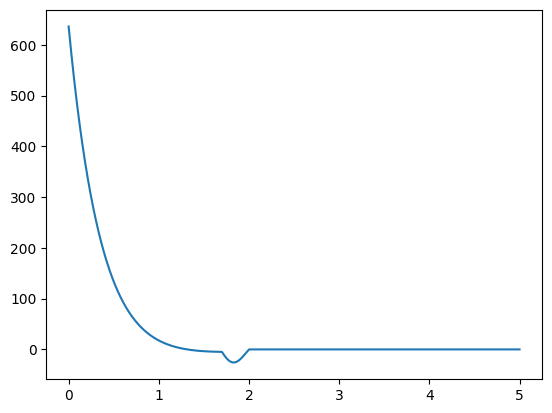

In [26]:
plt.plot(r[1:], -np.diff(rv-ra)/(r[1]-r[0]))
plt.show()

In [27]:
import sympy as sp

In [28]:
body_num = 3
dimention = 3

edge = int(body_num*(body_num - 1)/2)
N = body_num*dimention

q = sp.symbols('q_:{}'.format(N))
p = sp.symbols('p_:{}'.format(N))

m = sp.symbols('m:{}'.format(body_num))

R_e, R_1, R_2, S, beta, D_e, x, r = sp.symbols('R_e R_1 R_2 S \\beta D_e x r')

In [29]:
V=sp.Function('V')
G=sp.Function('G')

In [30]:
mat_U = sp.Matrix(body_num, body_num, lambda i, j:  G(V((sp.sqrt(sum((q[i*dimention+n] - q[j*dimention+n])**2 for n in range(0, dimention)))))))
for i in range(mat_U.rows):
    for j in range(mat_U.rows):
        if j >= i :
            mat_U[i,j] = 0
mat_U


Matrix([
[                                                              0,                                                               0, 0],
[G(V(sqrt((-q_0 + q_3)**2 + (-q_1 + q_4)**2 + (-q_2 + q_5)**2))),                                                               0, 0],
[G(V(sqrt((-q_0 + q_6)**2 + (-q_1 + q_7)**2 + (-q_2 + q_8)**2))), G(V(sqrt((-q_3 + q_6)**2 + (-q_4 + q_7)**2 + (-q_5 + q_8)**2))), 0]])

In [31]:
H = sum(mat_U)
H

G(V(sqrt((-q_0 + q_3)**2 + (-q_1 + q_4)**2 + (-q_2 + q_5)**2))) + G(V(sqrt((-q_0 + q_6)**2 + (-q_1 + q_7)**2 + (-q_2 + q_8)**2))) + G(V(sqrt((-q_3 + q_6)**2 + (-q_4 + q_7)**2 + (-q_5 + q_8)**2)))

In [32]:
H.diff(q[0])

(q_0 - q_3)*Derivative(G(V(sqrt((-q_0 + q_3)**2 + (-q_1 + q_4)**2 + (-q_2 + q_5)**2))), V(sqrt((-q_0 + q_3)**2 + (-q_1 + q_4)**2 + (-q_2 + q_5)**2)))*Subs(Derivative(V(_xi_1), _xi_1), _xi_1, sqrt((-q_0 + q_3)**2 + (-q_1 + q_4)**2 + (-q_2 + q_5)**2))/sqrt((-q_0 + q_3)**2 + (-q_1 + q_4)**2 + (-q_2 + q_5)**2) + (q_0 - q_6)*Derivative(G(V(sqrt((-q_0 + q_6)**2 + (-q_1 + q_7)**2 + (-q_2 + q_8)**2))), V(sqrt((-q_0 + q_6)**2 + (-q_1 + q_7)**2 + (-q_2 + q_8)**2)))*Subs(Derivative(V(_xi_1), _xi_1), _xi_1, sqrt((-q_0 + q_6)**2 + (-q_1 + q_7)**2 + (-q_2 + q_8)**2))/sqrt((-q_0 + q_6)**2 + (-q_1 + q_7)**2 + (-q_2 + q_8)**2)

In [33]:
H.diff(q[1])

(q_1 - q_4)*Derivative(G(V(sqrt((-q_0 + q_3)**2 + (-q_1 + q_4)**2 + (-q_2 + q_5)**2))), V(sqrt((-q_0 + q_3)**2 + (-q_1 + q_4)**2 + (-q_2 + q_5)**2)))*Subs(Derivative(V(_xi_1), _xi_1), _xi_1, sqrt((-q_0 + q_3)**2 + (-q_1 + q_4)**2 + (-q_2 + q_5)**2))/sqrt((-q_0 + q_3)**2 + (-q_1 + q_4)**2 + (-q_2 + q_5)**2) + (q_1 - q_7)*Derivative(G(V(sqrt((-q_0 + q_6)**2 + (-q_1 + q_7)**2 + (-q_2 + q_8)**2))), V(sqrt((-q_0 + q_6)**2 + (-q_1 + q_7)**2 + (-q_2 + q_8)**2)))*Subs(Derivative(V(_xi_1), _xi_1), _xi_1, sqrt((-q_0 + q_6)**2 + (-q_1 + q_7)**2 + (-q_2 + q_8)**2))/sqrt((-q_0 + q_6)**2 + (-q_1 + q_7)**2 + (-q_2 + q_8)**2)

In [34]:
H.diff(q[2])

(q_2 - q_5)*Derivative(G(V(sqrt((-q_0 + q_3)**2 + (-q_1 + q_4)**2 + (-q_2 + q_5)**2))), V(sqrt((-q_0 + q_3)**2 + (-q_1 + q_4)**2 + (-q_2 + q_5)**2)))*Subs(Derivative(V(_xi_1), _xi_1), _xi_1, sqrt((-q_0 + q_3)**2 + (-q_1 + q_4)**2 + (-q_2 + q_5)**2))/sqrt((-q_0 + q_3)**2 + (-q_1 + q_4)**2 + (-q_2 + q_5)**2) + (q_2 - q_8)*Derivative(G(V(sqrt((-q_0 + q_6)**2 + (-q_1 + q_7)**2 + (-q_2 + q_8)**2))), V(sqrt((-q_0 + q_6)**2 + (-q_1 + q_7)**2 + (-q_2 + q_8)**2)))*Subs(Derivative(V(_xi_1), _xi_1), _xi_1, sqrt((-q_0 + q_6)**2 + (-q_1 + q_7)**2 + (-q_2 + q_8)**2))/sqrt((-q_0 + q_6)**2 + (-q_1 + q_7)**2 + (-q_2 + q_8)**2)

In [35]:
mat_m = sp.Matrix.diag([((m[i]))  for i in range(0, body_num) for n in range(0, dimention)] ) 
mat_m

Matrix([
[m0,  0,  0,  0,  0,  0,  0,  0,  0],
[ 0, m0,  0,  0,  0,  0,  0,  0,  0],
[ 0,  0, m0,  0,  0,  0,  0,  0,  0],
[ 0,  0,  0, m1,  0,  0,  0,  0,  0],
[ 0,  0,  0,  0, m1,  0,  0,  0,  0],
[ 0,  0,  0,  0,  0, m1,  0,  0,  0],
[ 0,  0,  0,  0,  0,  0, m2,  0,  0],
[ 0,  0,  0,  0,  0,  0,  0, m2,  0],
[ 0,  0,  0,  0,  0,  0,  0,  0, m2]])

In [36]:
vect_P = [sp.Matrix([(p[i])  for i in range(N)])]
vect_P = sp.Matrix.vstack(*vect_P)

In [37]:
E_k = sp.Rational(1/2) * vect_P.T * mat_m.inv() * vect_P
E_k

Matrix([[p_6**2/(2*m2) + p_7**2/(2*m2) + p_8**2/(2*m2) + p_3**2/(2*m1) + p_4**2/(2*m1) + p_5**2/(2*m1) + p_0**2/(2*m0) + p_1**2/(2*m0) + p_2**2/(2*m0)]])

In [38]:
f=sp.Function('f')
g=sp.Function('g')

In [39]:
sp.diff(f(x)*g(x),x)


f(x)*Derivative(g(x), x) + g(x)*Derivative(f(x), x)

In [40]:
U = f(r)*(D_e/(S-1))*sp.exp(-beta*sp.sqrt(2*S)*(r-R_e)) - f(r)*(D_e*S/(S-1))*sp.exp(-beta*sp.sqrt(2/S)*(r-R_e))
U.diff(r)

-sqrt(2)*D_e*sqrt(S)*\beta*f(r)*exp(-sqrt(2)*sqrt(S)*\beta*(-R_e + r))/(S - 1) + sqrt(2)*D_e*S*\beta*sqrt(1/S)*f(r)*exp(-sqrt(2)*\beta*(-R_e + r)*sqrt(1/S))/(S - 1) - D_e*S*exp(-sqrt(2)*\beta*(-R_e + r)*sqrt(1/S))*Derivative(f(r), r)/(S - 1) + D_e*exp(-sqrt(2)*sqrt(S)*\beta*(-R_e + r))*Derivative(f(r), r)/(S - 1)

$$
B^*_{i,j} = \frac{B_{i,j} + B_{j,i}}{2}
$$
$$
\vec{r}_{i,j} = \vec{q}_{i} - \vec{q}_{j}
$$
$$
r_{i,j} = |\vec{r}_{i,j}|
$$
$$
B_{i,j} = \left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta}
$$
$$
\theta_{i,j,k} = \arccos(\frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}})
$$
$$
\vec{p}_i =  -\frac{1}{2}\frac{\partial}{\partial \vec{q}_i} \sum_{i}{\sum_{j\neq i}{U(r_{i,j})}}  = - \sum_{j \neq i}{\frac{\partial}{\partial r_{i,j} }U(r_{i,j})\frac{\vec{r}_{i,j}}{r_{i,j}}}
$$

$$
r_{i,j} = |\vec{r}_{i,j}|
$$
$$
\frac{\partial}{\partial r_{i,j}} \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]} 
$$
$$
\theta_{i,j,k} = \arccos(\frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}}) 
$$
$$
G(\theta_{i,j,k}) = a_0\left(1 + \frac{c_0^2}{d_0^2} - \frac{c_0^2}{d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2} \right)
$$

$$
\frac{\partial}{\partial r_{i,j}} G(\theta_{i,j,k}) = \frac{\partial}{\partial r_{i,j}} a_0\left(1 + \frac{c_0^2}{d_0^2} - \frac{c_0^2}{d_0^2 + (1 + \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}})^2} \right)
$$

$$
\frac{\partial}{\partial r_{i,j}} G(\theta_{i,j,k}) = 

-\frac{\partial}{\partial r_{i,j}} \frac{a_0 c_0^2}{d_0^2 + (1 + \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}})^2} 
$$

$$
\frac{\partial}{\partial r_{i,j}} G(\theta_{i,j,k}) = 

-\frac{a_0 c_0^2}{\left(d_0^2 + (1 + \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}})^2\right)^2} \frac{\partial}{\partial r_{i,j}} \left(d_0^2 + (1 + \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}})^2\right)
$$

$$
\frac{\partial}{\partial r_{i,j}} G(\theta_{i,j,k}) = 

-\frac{a_0 c_0^2}{\left(d_0^2 + (1 + \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}})^2\right)^2} 
\frac{\partial}{\partial r_{i,j}}   (1 + \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}})^2 
$$

$$
\frac{\partial}{\partial r_{i,j}} G(\theta_{i,j,k}) = 

-\frac{a_0 c_0^2}{\left(d_0^2 + (1 + \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}})^2\right)^2} 
  2(1 + \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}}) \frac{\partial}{\partial r_{i,j}} (1 + \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}})
$$

$$
\frac{\partial}{\partial r_{i,j}} G(\theta_{i,j,k}) = 

-\frac{a_0 c_0^2}{\left(d_0^2 + (1 + \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}})^2\right)^2} 
  2(1 + \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}}) \frac{\partial}{\partial r_{i,j}} \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}}
$$

$$
\frac{\partial}{\partial r_{i,j}} G(\theta_{i,j,k}) = 

-\frac{a_0 c_0^2}{\left(d_0^2 + (1 + \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}})^2\right)^2} 
  2(1 + \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}}) \frac{\partial}{\partial r_{i,j}} \frac{\vec{r}_{i,j}\vec{r}_{i,k}}{r_{i,j}r_{i,k}}
$$

$$
\vec{p}_i = -\frac{1}{2}\frac{\partial}{\partial \vec{q}_i} \sum_{i}{\sum_{j\neq i}{U(r_{i,j})}}  = 
-\frac{1}{2}\frac{\partial}{\partial \vec{q}_i} \sum_{i}{\sum_{j\neq i}{[V_R(r_{i,j}) - B_{i,j}^*V_A(r_{i,j})]}}  = 
$$
$$
-\frac{1}{2}\frac{\partial}{\partial \vec{q}_i} \sum_{i}{\sum_{j\neq i}{V_R(r_{i,j})}} +\frac{1}{2}\frac{\partial}{\partial \vec{q}_i} \sum_{i}{\sum_{j\neq i}{ B_{i,j}^*V_A(r_{i,j})}}  = 
$$

$$ 
- \sum_{j \neq i}{\frac{\partial}{\partial r_{i,j} }V_R(r_{i,j})\frac{\vec{r}_{i,j}}{r_{i,j}}}
+ \sum_{j \neq i}B_{i,j}^*{\frac{\partial}{\partial r_{i,j} }V_A(r_{i,j})\frac{\vec{r}_{i,j}}{r_{i,j}}}
+\frac{1}{2} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_i}B_{i,j}^*}}  = 
$$

$$
\frac{1}{2}\sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_i} B_{i,j}^*}} = 

$$

$$
\frac{\partial}{\partial \vec{q}_i} B_{i,j}^* = \frac{\partial}{\partial \vec{q}_i}\frac{B_{i,j} + B_{j,i}}{2} = \frac{1}{2}\frac{\partial}{\partial \vec{q}_i}(B_{i,j} +B_{j,i}) 
$$
$$
\frac{\partial}{\partial \vec{q}_i}B_{i,j} = \frac{\partial}{\partial \vec{q}_i}\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta} = 
$$


$$
\frac{\partial}{\partial \vec{q}_i}B_{i,j} =  
-\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} \frac{\partial}{\partial \vec{q}_i} \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}
$$

$$
\frac{\partial}{\partial \vec{q}_i} \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]} = 
 \sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial \vec{q}_i}f(r_{i,k})]} + \sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_i}G(\theta_{i,j,k})]}
$$

$$
\vec{r}_{i,k} = \vec{q}_{i} - \vec{q}_{k}
$$
$$
r_{i,k} = |\vec{r}_{i,k}|
$$
$$
n,i,j,k \in [0,N]
$$
$$
\frac{\partial}{\partial \vec{q}_n}f(r_{i,k}) = \frac{\partial}{\partial r_{i,k}}f(r_{i,k}) \frac{\partial}{\partial \vec{q}_n}|\vec{q}_{i} - \vec{q}_{k}| = 
 \frac{\partial}{\partial r_{i,k}}f(r_{i,k}) \frac{(\vec{q}_{i} - \vec{q}_{k})}{r_{i,k}} (\delta_n^i - \delta_n^k) = 
$$

$$
\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})(\delta_n^i - \delta_n^k) = 
\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^i - \frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^k =
$$

$$
\frac{\partial}{\partial \vec{q}_n}f(r_{i,k}) =\frac{\partial}{\partial r_{n,k}} f(r_{n,k}) \frac{1}{r_{n,k}} (\vec{q}_{n} - \vec{q}_{k}) - \frac{\partial}{\partial r_{i,n}} f(r_{i,n}) \frac{1}{r_{i,n}} (\vec{q}_{i} - \vec{q}_{n}) =
$$

$$
\frac{\partial}{\partial r_{n,k}} f(r_{n,k}) \frac{1}{r_{n,k}} (\vec{q}_{n} - \vec{q}_{k}) + \frac{\partial}{\partial r_{n,i}} f(r_{n,i}) \frac{1}{r_{n,i}} (\vec{q}_{n} - \vec{q}_{i}) 
$$

$$
\frac{\partial}{\partial \vec{q}_n} \sum_{k \neq i,j }{[G(\theta_{i,j,k}) f(r_{i,k})]} =  
\sum_{k \neq i,j }{[G(\theta_{i,j,k}) \left(\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^i - \frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^k\right)]} 
+ \sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k})]}
$$
$$
\frac{\partial}{\partial \vec{q}_n} \sum_{k \neq i,j }{[G(\theta_{i,j,k}) f(r_{i,k})]} =  
\sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^i]}
 - \sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^k ]} 
+ \sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k})]}
$$

$$
\frac{\partial}{\partial \vec{q}_n} \sum_{k \neq i,j }{[G(\theta_{i,j,k}) f(r_{i,k})]} =  

\sum_{k \neq n,j }{[G(\theta_{n,j,k})\frac{\partial}{\partial r_{n,k}} f(r_{n,k}) \frac{1}{r_{n,k}} (\vec{q}_{n} - \vec{q}_{k})]}

 + G(\theta_{i,j,n})\frac{\partial}{\partial r_{i,n}} f(r_{i,n}) \frac{1}{r_{i,n}} (\vec{q}_{n} - \vec{q}_{i})

+ \sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k})]}
$$

$$
G(\theta_{i,j,k}) = a_0\left(1 + \frac{c_0^2}{d_0^2} - \frac{c_0^2}{d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2} \right)
$$

$$
\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k}) = \frac{\partial}{\partial \vec{q}_n}G(\cos({\theta_{i,j,k}})) = \frac{\partial}{\partial \cos({\theta_{i,j,k}})}G(\cos({\theta_{i,j,k}}))\frac{\partial}{\partial \vec{q}_n}\cos({\theta_{i,j,k}}) = 
$$

$$ 
\left(\frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right)
\frac{\partial}{\partial \vec{q}_n}\cos({\theta_{i,j,k}}) = 
\left(\frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right)
\frac{\partial}{\partial \vec{q}_n}\frac{(\vec{q}_i - \vec{q}_j)\cdot(\vec{q}_i - \vec{q}_k) }{r_{i,j}r_{i,k}} = 
$$

$$ 
\left(\frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right)
\frac{1}{r_{i,j}r_{i,k}}\frac{\partial}{\partial \vec{q}_n}(\vec{q}_i - \vec{q}_j)(\vec{q}_i - \vec{q}_k)  = 

\left(\frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right)

\frac{1}{r_{i,j}r_{i,k}} \frac{\partial}{\partial \vec{q}_n}  (\vec{q}_i (\vec{q}_i - \vec{q}_j)  - \vec{q}_k (\vec{q}_i - \vec{q}_j) ) 

= 
$$

$$ 
\left(\frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right)

\frac{1}{r_{i,j}r_{i,k}} \frac{\partial}{\partial \vec{q}_n}  ((\vec{q}_i \vec{q}_i - \vec{q}_i \vec{q}_j)  -  (\vec{q}_k\vec{q}_i - \vec{q}_k\vec{q}_j) ) = 


$$

$$\frac{\partial}{\partial \cos({\theta_{i,j,k}})}G(\cos({\theta_{i,j,k}}))\frac{\partial}{\partial \vec{q}_n}\cos({\theta_{i,j,k}}) 

$$ 
\left(\frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right)

\frac{1}{r_{i,j}r_{i,k}}   ((\frac{\partial}{\partial \vec{q}_n}\vec{q}_i \vec{q}_i - \frac{\partial}{\partial \vec{q}_n}\vec{q}_i \vec{q}_j)  -  (\frac{\partial}{\partial \vec{q}_n}\vec{q}_k\vec{q}_i - \frac{\partial}{\partial \vec{q}_n}\vec{q}_k\vec{q}_j) ) = 

$$

$$
\frac{\partial}{\partial \vec{q}_n}\vec{q}_i \vec{q}_j = \vec{q}_i\delta_n^j + \vec{q}_j\delta_n^i 
$$

$$ 


\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right)\frac{\partial}{\partial \vec{q}_n}\vec{q}_i \vec{q}_i

 - \left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right)\frac{\partial}{\partial \vec{q}_n}\vec{q}_i \vec{q}_j

  -  \left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right)\frac{\partial}{\partial \vec{q}_n}\vec{q}_k\vec{q}_i 
  
  + \left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right)\frac{\partial}{\partial \vec{q}_n}\vec{q}_k\vec{q}_j = 

$$

$$ 

\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_i\delta_n^i + \vec{q}_i\delta_n^i )

 - \left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_i\delta_n^j + \vec{q}_j\delta_n^i )

  -  \left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_k\delta_n^i + \vec{q}_i\delta_n^k )
  
  + \left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_k\delta_n^j + \vec{q}_j\delta_n^k )
  =  

$$

$$ 

\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_i\delta_n^i + \vec{q}_i\delta_n^i )

 - \left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_i\delta_n^i + \vec{q}_j\delta_n^j )

  -  \left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_k\delta_n^k + \vec{q}_i\delta_n^i )
  
  + \left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_k\delta_n^k + \vec{q}_j\delta_n^j )

$$

$$
\sum_{k \neq i,j }{[f(r_{i,k})(\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_i\delta_n^i + \vec{q}_i\delta_n^i )

 - \left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_i\delta_n^j + \vec{q}_j\delta_n^i )

  -  \left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_k\delta_n^i + \vec{q}_i\delta_n^k )
  
  + \left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_k\delta_n^j + \vec{q}_j\delta_n^k ))]}
$$

term 1

$$
\sum_{k \neq i,j }{f(r_{i,k})\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2}\right)\vec{q}_i\delta_n^i }
+ \sum_{k \neq i,j }{f(r_{i,k})\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2}\right)\vec{q}_i\delta_n^i } = 
$$
$$
2\sum_{k \neq i,j }{f(r_{i,k})\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2}\right)\vec{q}_i\delta_n^i }= 
$$
$$
2\sum_{k \neq n,j }{f(r_{n,k})\left(\frac{1}{r_{n,j}r_{n,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{n,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{n,j,k})})^2)^2}\right)\vec{q}_n }
$$

term 2
$$
\sum_{k \neq i,j }{f(r_{i,k})\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_i\delta_n^j + \vec{q}_j\delta_n^i)} = 

\sum_{k \neq i,j }{f(r_{i,k})\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right)\vec{q}_i\delta_n^j}
+
\sum_{k \neq i,j }{f(r_{i,k})\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) \vec{q}_j\delta_n^i} = 
$$

 
$$
\sum_{k \neq i,n }{f(r_{i,k})\left(\frac{1}{r_{i,n}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,n,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,n,k})})^2)^2} \right)\vec{q}_i}
+
\sum_{k \neq n,j }{f(r_{n,k})\left(\frac{1}{r_{n,j}r_{n,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{n,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{n,j,k})})^2)^2} \right) \vec{q}_j } 
$$

term 3
$$
\sum_{k \neq i,j }{f(r_{i,k})\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_k\delta_n^i + \vec{q}_i\delta_n^k )} 
=
\sum_{k \neq i,j }{f(r_{i,k})\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) \vec{q}_k\delta_n^i}
+
\sum_{k \neq i,j }{f(r_{i,k})\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) \vec{q}_i\delta_n^k}
= 
$$
$$
\sum_{k \neq n,j }{f(r_{n,k})\left(\frac{1}{r_{n,j}r_{n,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{n,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{n,j,k})})^2)^2} \right) \vec{q}_k }
+
f(r_{i,n})\left(\frac{1}{r_{i,j}r_{i,n}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,n})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,n})})^2)^2} \right) \vec{q}_i 
= 
$$

term 4

$$
\sum_{k \neq i,j }{f(r_{i,k})\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) (\vec{q}_k\delta_n^j + \vec{q}_j\delta_n^k )} 
= 
\sum_{k \neq i,j }{f(r_{i,k})\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) \vec{q}_k\delta_n^j}
+
\sum_{k \neq i,j }{f(r_{i,k})\left(\frac{1}{r_{i,j}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) \vec{q}_j\delta_n^k} 
= 
$$
$$
\sum_{k \neq i,n }{f(r_{i,k})\left(\frac{1}{r_{i,n}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,n,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,n,k})})^2)^2} \right) \vec{q}_k }
+
 f(r_{i,n})\left(\frac{1}{r_{i,j}r_{i,n}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,n})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,n})})^2)^2} \right) \vec{q}_j 
$$

$$
\sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k})]} = 
2\sum_{k \neq n,j }{f(r_{n,k})\left(\frac{1}{r_{n,j}r_{n,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{n,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{n,j,k})})^2)^2}\right)\vec{q}_n }
-
\sum_{k \neq i,n }{f(r_{i,k})\left(\frac{1}{r_{i,n}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,n,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,n,k})})^2)^2} \right)\vec{q}_i}
-
\sum_{k \neq n,j }{f(r_{n,k})\left(\frac{1}{r_{n,j}r_{n,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{n,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{n,j,k})})^2)^2} \right) \vec{q}_j } 
-
$$
$$
\sum_{k \neq n,j }{f(r_{n,k})\left(\frac{1}{r_{n,j}r_{n,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{n,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{n,j,k})})^2)^2} \right) \vec{q}_k }
-
f(r_{i,n})\left(\frac{1}{r_{i,j}r_{i,n}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,n})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,n})})^2)^2} \right) \vec{q}_i 
+
\sum_{k \neq i,n }{f(r_{i,k})\left(\frac{1}{r_{i,n}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,n,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,n,k})})^2)^2} \right) \vec{q}_k }
+
 f(r_{i,n})\left(\frac{1}{r_{i,j}r_{i,n}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,n})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,n})})^2)^2} \right) \vec{q}_j 
$$

$$
\sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k})]} = 

\sum_{k \neq n,j }{f(r_{n,k})\left(\frac{1}{r_{n,j}r_{n,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{n,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{n,j,k})})^2)^2}\right)(\vec{q}_n - \vec{q}_j)} 
+
\sum_{k \neq n,j }{f(r_{n,k})\left(\frac{1}{r_{n,j}r_{n,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{n,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{n,j,k})})^2)^2}\right)(\vec{q}_n - \vec{q}_k)}
$$
$$
+
\sum_{k \neq i,n }{f(r_{i,k})\left(\frac{1}{r_{i,n}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,n,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,n,k})})^2)^2}\right) (\vec{q}_k - \vec{q}_i)}
+
f(r_{i,n})\left(\frac{1}{r_{i,j}r_{i,n}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,n})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,n})})^2)^2}\right)(\vec{q}_j - \vec{q}_i)
$$

$$
\vec{p}_n = -\frac{1}{2}\frac{\partial}{\partial \vec{q}_n} \sum_{i}{\sum_{j\neq i}{U(r_{i,j})}}  = 
-\frac{1}{2}\frac{\partial}{\partial \vec{q}_n} \sum_{i}{\sum_{j\neq i}{[V_R(r_{i,j}) - B_{i,j}^*V_A(r_{i,j})]}}  = 
$$
$$
-\frac{1}{2}\frac{\partial}{\partial \vec{q}_n} \sum_{i}{\sum_{j\neq i}{V_R(r_{i,j})}} 
+\frac{1}{2}\frac{\partial}{\partial \vec{q}_n} \sum_{i}{\sum_{j\neq i}{ B_{i,j}^*V_A(r_{i,j})}}  = 

- \sum_{j \neq n}{\frac{\partial}{\partial r_{n,j} }V_R(r_{n,j})\frac{\vec{r}_{n,j}}{r_{n,j}}}
+ \sum_{j \neq n}B_{n,j}^*{\frac{\partial}{\partial r_{n,j} }V_A(r_{n,j})\frac{\vec{r}_{n,j}}{r_{n,j}}}
+\frac{1}{2} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_n}B_{i,j}^*}} 
$$

$$
\frac{\partial}{\partial \vec{q}_n}B_{i,j} = 
 -\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} \left[\sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial \vec{q}_n}f(r_{i,k})]} + \sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k})]}\right]
$$

$$
\frac{\partial}{\partial \vec{q}_n}B_{i,j} = 
 -\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} 
 
 \left[
    
    \sum_{k \neq n,j }{[G(\theta_{n,j,k})\frac{\partial}{\partial r_{n,k}} f(r_{n,k}) \frac{1}{r_{n,k}} (\vec{q}_{n} - \vec{q}_{k})]}

 + G(\theta_{i,j,n})\frac{\partial}{\partial r_{i,n}} f(r_{i,n}) \frac{1}{r_{i,n}} (\vec{q}_{n} - \vec{q}_{i})
 
 + \sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k})]}
 
 \right]
$$

$$
\frac{\partial}{\partial \vec{q}_n}B_{i,j} = 
 -\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} 
 
 \left[
    \sum_{k \neq n,j }{[G(\theta_{n,j,k})\frac{\partial}{\partial r_{n,k}} f(r_{n,k}) \frac{1}{r_{n,k}} (\vec{q}_{n} - \vec{q}_{k})]}
 + 
 G(\theta_{i,j,n})\frac{\partial}{\partial r_{i,n}} f(r_{i,n}) \frac{1}{r_{i,n}} (\vec{q}_{n} - \vec{q}_{i})
 + 
 \sum_{k \neq n,j }{f(r_{n,k})\left(\frac{1}{r_{n,j}r_{n,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{n,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{n,j,k})})^2)^2}\right)(\vec{q}_n - \vec{q}_j)} 
+
\sum_{k \neq n,j }{f(r_{n,k})\left(\frac{1}{r_{n,j}r_{n,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{n,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{n,j,k})})^2)^2}\right)(\vec{q}_n - \vec{q}_k)}

+
\sum_{k \neq i,n }{f(r_{i,k})\left(\frac{1}{r_{i,n}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,n,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,n,k})})^2)^2}\right) (\vec{q}_k - \vec{q}_i)}
+
f(r_{i,n})\left(\frac{1}{r_{i,j}r_{i,n}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,n})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,n})})^2)^2}\right)(\vec{q}_j - \vec{q}_i)
 \right]
$$

$$
\frac{\partial}{\partial \vec{q}_n}B_{i,j} = 
 -\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} 
 
 \left[
    \sum_{k \neq n,j }{[G(\theta_{n,j,k})\frac{\partial}{\partial r_{n,k}} f(r_{n,k}) \frac{1}{r_{n,k}} (\vec{q}_{n} - \vec{q}_{k})]}
 + 
 G(\theta_{i,j,n})\frac{\partial}{\partial r_{i,n}} f(r_{i,n}) \frac{1}{r_{i,n}} (\vec{q}_{n} - \vec{q}_{i})
 + 
 \sum_{k \neq n,j }{f(r_{n,k})\left(\frac{1}{r_{n,j}r_{n,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{n,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{n,j,k})})^2)^2}\right)(\vec{q}_n - \vec{q}_j)}
 \right.
$$
$$\left.
+
\sum_{k \neq n,j }{f(r_{n,k})\left(\frac{1}{r_{n,j}r_{n,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{n,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{n,j,k})})^2)^2}\right)(\vec{q}_n - \vec{q}_k)}

+
\sum_{k \neq i,n }{f(r_{i,k})\left(\frac{1}{r_{i,n}r_{i,k}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,n,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,n,k})})^2)^2}\right) (\vec{q}_k - \vec{q}_i)}
+
f(r_{i,n})\left(\frac{1}{r_{i,j}r_{i,n}} \frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,n})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,n})})^2)^2}\right)(\vec{q}_j - \vec{q}_i)
 \right]
$$

$$
\sum_{k \neq n,j }{[G(\theta_{n,j,k})\frac{\partial}{\partial r_{n,k}} f(r_{n,k}) \frac{1}{r_{n,k}} (\vec{q}_{n} - \vec{q}_{k})]}

 + G(\theta_{i,j,n})\frac{\partial}{\partial r_{i,n}} f(r_{i,n}) \frac{1}{r_{i,n}} (\vec{q}_{n} - \vec{q}_{i})
$$

еще раз

$$
\vec{p}_n = -\frac{1}{2}\frac{\partial}{\partial \vec{q}_n} \sum_{i}{\sum_{j\neq i}{U(r_{i,j})}}  = 
-\frac{1}{2}\frac{\partial}{\partial \vec{q}_n} \sum_{i}{\sum_{j\neq i}{[V_R(r_{i,j}) - B_{i,j}^*V_A(r_{i,j})]}}  = 
$$
$$
-\frac{1}{2}\frac{\partial}{\partial \vec{q}_n} \sum_{i}{\sum_{j\neq i}{V_R(r_{i,j})}} 
+\frac{1}{2}\frac{\partial}{\partial \vec{q}_n} \sum_{i}{\sum_{j\neq i}{ B_{i,j}^*V_A(r_{i,j})}}  = 

- \sum_{j \neq n}{\frac{\partial}{\partial r_{n,j} }V_R(r_{n,j})\frac{\vec{r}_{n,j}}{r_{n,j}}}
+ \sum_{j \neq n}B_{n,j}^*{\frac{\partial}{\partial r_{n,j} }V_A(r_{n,j})\frac{\vec{r}_{n,j}}{r_{n,j}}}
+\frac{1}{2} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_n}B_{i,j}^*}} 
$$

$$
\frac{1}{2} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_n}B_{i,j}^*}} =
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_n} B_{i,j}}} +\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j})\frac{\partial}{\partial \vec{q}_n} B_{j,i}}} =
$$

$$ 
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_n} B_{i,j}}} = 
-\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} \left[\sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial \vec{q}_n}f(r_{i,k})]} 
 + \sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k})]}\right]}} =
$$

$$
-\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} \left[\sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial \vec{q}_n}f(r_{i,k})]} 
 + \sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k})]}\right]}}  = 
$$

$$
-\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} \sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial \vec{q}_n}f(r_{i,k})]} }}  
-
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} \sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k})]} }}  =
$$

$$
-term_1
-
term_2
$$

term 1
$$
-\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1}  

(\sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^i]}

 - \sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^k ]} )}}
$$

$$
-\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1}  

\sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^i]}}}

+\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1}  

\sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^k ]}}}
$$

$$
term_1 = -\frac{1}{4} \sum_{j\neq n}{V_A(r_{n,j}) 
\delta\left(1 + \sum_{k \neq n,j }{[G(\theta_{n,j,k})f(r_{n,k})]}\right)^{-\delta-1}  

\sum_{k \neq n,j }{[G(\theta_{n,j,k})\frac{\partial}{\partial r_{n,k}} f(r_{n,k}) \frac{1}{r_{n,k}} (\vec{q}_{n} - \vec{q}_{k})]}}
$$
$$
+\frac{1}{4} \sum_{i \neq n}{\sum_{j\neq i,n}{V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j}{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1}  

G(\theta_{i,j,n})\frac{\partial}{\partial r_{i,n}} f(r_{i,n}) \frac{1}{r_{i,n}} (\vec{q}_{i} - \vec{q}_{n})}}
$$

term 2

$$
-
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} \sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k})]} }}=
$$

$$
G(\theta_{i,j,k}) = a_0\left(1 + \frac{c_0^2}{d_0^2} - \frac{c_0^2}{d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2} \right)
$$

$$
1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]} = K_{i,j,k}
$$
$$
-
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(K_{i,j,k}\right)^{-\delta-1} \sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k})]} }}=
-
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(K_{i,j,k}\right)^{-\delta-1} \sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\cos({\theta_{i,j,k}}))]} }}
$$

$$
 =
-
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(K_{i,j,k}\right)^{-\delta-1} \sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\cos({\theta_{i,j,k}}))]} }}
$$

$$
\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k}) = \frac{\partial}{\partial \vec{q}_n}G(\cos({\theta_{i,j,k}})) = \frac{\partial}{\partial \cos({\theta_{i,j,k}})}G(\cos({\theta_{i,j,k}}))\frac{\partial}{\partial \vec{q}_n}\cos({\theta_{i,j,k}}) = 
$$

$$
\frac{\partial}{\partial \vec{q}_n}\vec{q}_i \vec{q}_j = \vec{q}_i\delta_n^j + \vec{q}_j\delta_n^i 
$$

$$
\frac{\partial}{\partial \vec{q}_n}\cos({\theta_{i,j,k}}) = \frac{\partial}{\partial \vec{q}_n}\frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)}{r_{i,j}r_{i,k}}=
% \frac{1}{r_{i,j}r_{i,k}}   ((\frac{\partial}{\partial \vec{q}_n}\vec{q}_i \vec{q}_i - \frac{\partial}{\partial \vec{q}_n}\vec{q}_i \vec{q}_j)  -  (\frac{\partial}{\partial \vec{q}_n}\vec{q}_k\vec{q}_i - \frac{\partial}{\partial \vec{q}_n}\vec{q}_k\vec{q}_j) ) = 
$$


$$
\frac{\partial}{\partial \vec{q}_n}\frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)}{|\vec{q}_i-\vec{q}_j| |\vec{q}_i-\vec{q}_k|} = 
$$


$$
\frac{1}{|\vec{q}_i-\vec{q}_j| |\vec{q}_i-\vec{q}_k|}\frac{\partial}{\partial \vec{q}_n} (\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)
+ (\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)\frac{\partial}{\partial \vec{q}_n}\frac{1}{|\vec{q}_i-\vec{q}_j| |\vec{q}_i-\vec{q}_k|} 
$$


$$
\frac{\partial}{\partial \vec{q}_n} (\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k) = 
\frac{\partial}{\partial \vec{q}_n} ((\vec{q}_i-\vec{q}_j)\cdot\vec{q}_i-(\vec{q}_i-\vec{q}_j)\cdot\vec{q}_k) = 
$$

$$
\frac{\partial}{\partial \vec{q}_n} ((\vec{q}_i\cdot\vec{q}_i-\vec{q}_j\cdot\vec{q}_i)-(\vec{q}_i\cdot\vec{q}_k-\vec{q}_j\cdot\vec{q}_k)) = 
\frac{\partial}{\partial \vec{q}_n} (\vec{q}_i\cdot\vec{q}_i-\vec{q}_j\cdot\vec{q}_i-\vec{q}_i\cdot\vec{q}_k+\vec{q}_j\cdot\vec{q}_k) =
$$

$$ 
\frac{\partial}{\partial \vec{q}_n} (\vec{q}_i\cdot\vec{q}_i-\vec{q}_j\cdot\vec{q}_i-\vec{q}_i\cdot\vec{q}_k+\vec{q}_j\cdot\vec{q}_k) = 
2\vec{q}_i\delta_n^i - \vec{q}_j\delta_n^i - \vec{q}_i\delta_n^j - \vec{q}_i\delta_n^k - \vec{q}_k\delta_n^i + \vec{q}_k\delta_n^j + \vec{q}_j\delta_n^k =
$$  

$$ 
(2\vec{q}_i - \vec{q}_k - \vec{q}_j)\delta_n^i   + (\vec{q}_k  - \vec{q}_i)\delta_n^j + (\vec{q}_j - \vec{q}_i)\delta_n^k
$$  

$$
\frac{\partial}{\partial \vec{q}_n} (\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k) = 
(2\vec{q}_i - \vec{q}_k - \vec{q}_j)\delta_n^i   + (\vec{q}_k  - \vec{q}_i)\delta_n^j + (\vec{q}_j - \vec{q}_i)\delta_n^k
$$

$$
  \frac{(\vec{q}_{i} - \vec{q}_{j})}{r_{i,j}} (\delta_n^i - \delta_n^j) + \frac{(\vec{q}_{i} - \vec{q}_{k})}{r_{i,k}} (\delta_n^i - \delta_n^k)

$$
\frac{\partial}{\partial \vec{q}_n}\frac{1}{|\vec{q}_i-\vec{q}_j| |\vec{q}_i-\vec{q}_k|} = 
-\frac{|\vec{q}_i-\vec{q}_k|\frac{\partial}{\partial \vec{q}_n}|\vec{q}_i-\vec{q}_j| + |\vec{q}_i-\vec{q}_j|\frac{\partial}{\partial \vec{q}_n} |\vec{q}_i-\vec{q}_k|}{(|\vec{q}_i-\vec{q}_j| |\vec{q}_i-\vec{q}_k|)^2} = 

-\frac{|\vec{q}_i-\vec{q}_k|\frac{(\vec{q}_{i} - \vec{q}_{j})}{r_{i,j}} (\delta_n^i - \delta_n^j) + |\vec{q}_i-\vec{q}_j|\frac{(\vec{q}_{i} - \vec{q}_{k})}{r_{i,k}} (\delta_n^i - \delta_n^k)} {(|\vec{q}_i-\vec{q}_j| |\vec{q}_i-\vec{q}_k|)^2} = 

$$

$$
-
\frac{(\vec{q}_{i} - \vec{q}_{j})(\delta_n^i - \delta_n^j) } {r_{i,j}^3 r_{i,k}} 
- 
\frac{(\vec{q}_{i} - \vec{q}_{k}) (\delta_n^i - \delta_n^k)} {r_{i,j} r_{i,k}^3} 
$$

$$
\frac{\partial}{\partial \vec{q}_n} (\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k) = 
(2\vec{q}_i - \vec{q}_k - \vec{q}_j)\delta_n^i   + (\vec{q}_k  - \vec{q}_i)\delta_n^j + (\vec{q}_j - \vec{q}_i)\delta_n^k
$$

$$
\frac{\partial}{\partial \vec{q}_n}\cos({\theta_{i,j,k}}) =  

\frac{(2\vec{q}_i - \vec{q}_k - \vec{q}_j)\delta_n^i  + (\vec{q}_k  - \vec{q}_i)\delta_n^j + (\vec{q}_j - \vec{q}_i)\delta_n^k}{r_{i,j} r_{i,k}} 
 
-
\frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{j}) } {r_{i,j}^3 r_{i,k}} (\delta_n^i - \delta_n^j)
- 
\frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{k}) } {r_{i,j} r_{i,k}^3} (\delta_n^i - \delta_n^k)

$$


$$
\frac{\partial}{\partial \cos({\theta_{i,j,k}})}G(\cos({\theta_{i,j,k}})) = 
\left(\frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) = H_{i,j,k}
$$

$$
\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k})   =  

 H_{i,j,k} \frac{(2\vec{q}_i - \vec{q}_k - \vec{q}_j)\delta_n^i  + (\vec{q}_k  - \vec{q}_i)\delta_n^j + (\vec{q}_j - \vec{q}_i)\delta_n^k}{r_{i,j} r_{i,k}} 
 
-
 H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{j}) } {r_{i,j}^3 r_{i,k}} (\delta_n^i - \delta_n^j)
- 
 H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{k}) } {r_{i,j} r_{i,k}^3} (\delta_n^i - \delta_n^k)
$$

$$
-
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} \sum_{k \neq i,j }{[f(r_{i,k})\frac{\partial}{\partial \vec{q}_n}G(\theta_{i,j,k})]} }}=
$$

итог не syms

$$
-
\frac{1}{4} \sum_{i}\sum_{j\neq i}V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} \sum_{k \neq i,j }
f(r_{i,k}) 

H_{i,j,k} \frac{(2\vec{q}_i - \vec{q}_k - \vec{q}_j)\delta_n^i  + (\vec{q}_k  - \vec{q}_i)\delta_n^j + (\vec{q}_j - \vec{q}_i)\delta_n^k}{r_{i,j} r_{i,k}} 
$$
$$
-
 H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{j}) } {r_{i,j}^3 r_{i,k}} (\delta_n^i - \delta_n^j)
- 
 H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{k}) } {r_{i,j} r_{i,k}^3} (\delta_n^i - \delta_n^k) 
=

$$

$$
-
\frac{1}{4} \sum_{i}\sum_{j\neq i}V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} \sum_{k \neq i,j }
f(r_{i,k}) 

 \frac{H_{i,j,k}}{r_{i,j} r_{i,k}}((2\vec{q}_i - \vec{q}_k - \vec{q}_j)\delta_n^i  + (\vec{q}_k  - \vec{q}_i)\delta_n^j + (\vec{q}_j - \vec{q}_i)\delta_n^k )=

$$

$$
-
\frac{1}{4} \sum_{i}\sum_{j\neq i}V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} \sum_{k \neq i,j }
f(r_{i,k}) \frac{H_{i,j,k}}{r_{i,j} r_{i,k}} (2\vec{q}_i - \vec{q}_k - \vec{q}_j)\delta_n^i  
$$
$$
-
\frac{1}{4} \sum_{i}\sum_{j\neq i}V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} \sum_{k \neq i,j }
f(r_{i,k}) \frac{H_{i,j,k}}{r_{i,j} r_{i,k}} (\vec{q}_k  - \vec{q}_i)\delta_n^j 
$$
$$
-
\frac{1}{4} \sum_{i}\sum_{j\neq i}V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} \sum_{k \neq i,j }
f(r_{i,k}) \frac{H_{i,j,k}}{r_{i,j} r_{i,k}} (\vec{q}_j - \vec{q}_i)\delta_n^k =

$$

$$
 
-
\frac{1}{4} \sum_{j\neq i}V_A(r_{n,j}) 
\delta\left(1 + \sum_{k \neq n,j }{[G(\theta_{n,j,k})f(r_{n,k})]}\right)^{-\delta-1} \sum_{k \neq n,j }
f(r_{n,k}) \frac{H_{n,j,k}}{r_{n,j} r_{n,k}} (2\vec{q}_n - \vec{q}_k - \vec{q}_j) 
$$
$$
-
\frac{1}{4} \sum_{i} V_A(r_{i,n}) 
\delta\left(1 + \sum_{k \neq i,n }{[G(\theta_{i,n,k})f(r_{i,k})]}\right)^{-\delta-1} \sum_{k \neq i,n }
f(r_{i,k}) \frac{H_{i,n,k}}{r_{i,n} r_{i,k}} (\vec{q}_k  - \vec{q}_i)
$$
$$
-
\frac{1}{4} \sum_{i}\sum_{j\neq i, n\neq i,j}V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1}  
f(r_{i,n}) \frac{H_{i,j,n}}{r_{i,j} r_{i,n}} (\vec{q}_j - \vec{q}_i) 

$$

$$
 
-
\frac{1}{4} \sum_{j\neq i}V_A(r_{n,j}) 
\delta\left(K_{n,j,k}\right)^{-\delta-1} \sum_{k \neq n,j }
f(r_{n,k}) \frac{H_{n,j,k}}{r_{n,j} r_{n,k}} (2\vec{q}_n - \vec{q}_k - \vec{q}_j) 
$$
$$
-
\frac{1}{4} \sum_{i} V_A(r_{i,n}) 
\delta\left(K_{i,n,k}\right)^{-\delta-1} \sum_{k \neq i,n }
f(r_{i,k}) \frac{H_{i,n,k}}{r_{i,n} r_{i,k}} (\vec{q}_k  - \vec{q}_i)
$$
$$
-
\frac{1}{4} \sum_{i}\sum_{j\neq i, n\neq i,j}V_A(r_{i,j}) 
\delta\left(K_{i,j,k}\right)^{-\delta-1}  
f(r_{i,n}) \frac{H_{i,j,n}}{r_{i,j} r_{i,n}} (\vec{q}_j - \vec{q}_i) 
$$

$$
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_n} B_{i,j}}} = 
$$
$$
-\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1}  

(\sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^i]}

 - \sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^k ]} )}}
$$
$$
-
\frac{1}{4} \sum_{i}\sum_{j\neq i}V_A(r_{i,j}) 
\delta\left(1 + \sum_{k \neq i,j }{[G(\theta_{i,j,k})f(r_{i,k})]}\right)^{-\delta-1} \sum_{k \neq i,j }
f(r_{i,k}) 

H_{i,j,k} \frac{(2\vec{q}_i - \vec{q}_k - \vec{q}_j)\delta_n^i  + (\vec{q}_k  - \vec{q}_i)\delta_n^j + (\vec{q}_j - \vec{q}_i)\delta_n^k}{r_{i,j} r_{i,k}} 
$$
$$
-
 H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{j}) } {r_{i,j}^3 r_{i,k}} (\delta_n^i - \delta_n^j)
- 
 H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{k}) } {r_{i,j} r_{i,k}^3} (\delta_n^i - \delta_n^k) 

$$

$$
\vec{p}_n = 

- \sum_{j \neq n}{\frac{\partial}{\partial r_{n,j} }V_R(r_{n,j})\frac{\vec{r}_{n,j}}{r_{n,j}}}
+ \sum_{j \neq n}B_{n,j}^*{\frac{\partial}{\partial r_{n,j} }V_A(r_{n,j})\frac{\vec{r}_{n,j}}{r_{n,j}}}
+\frac{1}{2} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_n}B_{i,j}^*}} 
$$

$$
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_n} B_{i,j}}} = 
$$
$$
-\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(K_{i,j,k}\right)^{-\delta-1}  

(\sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^i]}

 - \sum_{k \neq i,j }{[G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^k ]} )}}
$$
$$
-
\frac{1}{4} \sum_{i}\sum_{j\neq i}V_A(r_{i,j}) 
\delta\left(K_{i,j,k}\right)^{-\delta-1} \sum_{k \neq i,j }
f(r_{i,k}) (

H_{i,j,k} \frac{(2\vec{q}_i - \vec{q}_k - \vec{q}_j)\delta_n^i  + (\vec{q}_k  - \vec{q}_i)\delta_n^j + (\vec{q}_j - \vec{q}_i)\delta_n^k}{r_{i,j} r_{i,k}} 
$$
$$
-
 H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{j}) } {r_{i,j}^3 r_{i,k}} (\delta_n^i - \delta_n^j)
- 
 H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{k}) } {r_{i,j} r_{i,k}^3} (\delta_n^i - \delta_n^k) )

$$

$$
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_n} B_{j,i}}} = 
$$

$$
-\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{j,i}) 
\delta\left(K_{j,i,k}\right)^{-\delta-1}  

(\sum_{k \neq j,i }{[G(\theta_{j,i,k})\frac{\partial}{\partial r_{j,k}} f(r_{j,k}) \frac{1}{r_{j,k}} (\vec{q}_{j} - \vec{q}_{k})\delta_n^j]}

 - \sum_{k \neq j,i }{[G(\theta_{j,i,k})\frac{\partial}{\partial r_{j,k}} f(r_{j,k}) \frac{1}{r_{j,k}} (\vec{q}_{j} - \vec{q}_{k})\delta_n^k ]} )}}
$$
$$
-
\frac{1}{4} \sum_{i}\sum_{j\neq i}V_A(r_{j,i}) 
\delta\left(K_{j,i,k}\right)^{-\delta-1} \sum_{k \neq j,i }
f(r_{j,k}) (

H_{j,i,k} \frac{(2\vec{q}_j - \vec{q}_k - \vec{q}_i)\delta_n^j  + (\vec{q}_k  - \vec{q}_j)\delta_n^i + (\vec{q}_i - \vec{q}_j)\delta_n^k}{r_{j,i} r_{j,k}} 
$$
$$
-
 H_{j,i,k} \frac{(\vec{q}_j-\vec{q}_i)\cdot(\vec{q}_j-\vec{q}_k)(\vec{q}_{j} - \vec{q}_{i}) } {r_{j,i}^3 r_{j,k}} (\delta_n^j - \delta_n^i)
- 
 H_{j,i,k} \frac{(\vec{q}_j-\vec{q}_i)\cdot(\vec{q}_j-\vec{q}_k)(\vec{q}_{j} - \vec{q}_{k}) } {r_{j,i} r_{j,k}^3} (\delta_n^j - \delta_n^k) )

$$


$$ 
\left(\frac{2 a_0 c_0^2 (1 + \cos{(\theta_{i,j,k})}) }{(d_0^2 + (1 + \cos{(\theta_{i,j,k})})^2)^2} \right) = H_{i,j,k}
$$

$$
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_n} B_{i,j}}} = 
$$
$$
-\frac{1}{4} \sum_{i}\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(K_{i,j,k}\right)^{-\delta-1}  

\sum_{k \neq i,j }
\left([G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^i]\right.

 - [G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^k ]} 
$$
$$
- 
f(r_{i,k}) (

H_{i,j,k} \frac{(2\vec{q}_i - \vec{q}_k - \vec{q}_j)\delta_n^i  + (\vec{q}_k  - \vec{q}_i)\delta_n^j + (\vec{q}_j - \vec{q}_i)\delta_n^k}{r_{i,j} r_{i,k}} 
$$
$$
-
 H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{j}) } {r_{i,j}^3 r_{i,k}} (\delta_n^i - \delta_n^j)
- 
 \left. H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{k}) } {r_{i,j} r_{i,k}^3} (\delta_n^i - \delta_n^k) )\right)

$$

$$
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_n} B_{i,j}}} = 
$$
$$
-\frac{1}{4} \sum_{i}\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(K_{i,j,k}\right)^{-\delta-1}  

\sum_{k \neq i,j }

\left([G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^i]\right.

 - [G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^k ]} 
$$
$$
- 

f(r_{i,k}) H_{i,j,k} \frac{(2\vec{q}_i - \vec{q}_k - \vec{q}_j)\delta_n^i  + (\vec{q}_k  - \vec{q}_i)\delta_n^j + (\vec{q}_j - \vec{q}_i)\delta_n^k}{r_{i,j} r_{i,k}} 
$$
$$
+
 f(r_{i,k})H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{j}) } {r_{i,j}^3 r_{i,k}} (\delta_n^i - \delta_n^j)
+ 
 \left. f(r_{i,k})H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{k}) } {r_{i,j} r_{i,k}^3} (\delta_n^i - \delta_n^k) \right)

$$

$$
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_n} B_{i,j}}} = 
$$
$$
-\frac{1}{4} \sum_{i}\sum_{j\neq i}{V_A(r_{i,j}) 
\delta\left(K_{i,j,k}\right)^{-\delta-1}  

\sum_{k \neq i,j }

\left([G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^i]\right.

 - [G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^k ]} 
$$
$$
- 
f(r_{i,k}) H_{i,j,k} \frac{(2\vec{q}_i - \vec{q}_k - \vec{q}_j)\delta_n^i }{r_{i,j} r_{i,k}} 
-
f(r_{i,k}) H_{i,j,k} \frac{(\vec{q}_k  - \vec{q}_i)\delta_n^j}{r_{i,j} r_{i,k}} 
-
f(r_{i,k}) H_{i,j,k} \frac{(\vec{q}_j - \vec{q}_i)\delta_n^k}{r_{i,j} r_{i,k}} 

$$
$$ \left.
+
f(r_{i,k})H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{j}) } {r_{i,j}^3 r_{i,k}} \delta_n^i 
-
f(r_{i,k})H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{j}) } {r_{i,j}^3 r_{i,k}} \delta_n^j
+ 
 f(r_{i,k})H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{k}) } {r_{i,j} r_{i,k}^3} \delta_n^i 
 -
 f(r_{i,k})H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{k}) } {r_{i,j} r_{i,k}^3} \delta_n^k \right)

$$

$$
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_n} B_{i,j}}} = 
$$
$$
-\frac{1}{4} \sum_{i}\sum_{j\neq i}V_A(r_{i,j}) 
\delta\left(K_{i,j,k}\right)^{-\delta-1}  

\sum_{k \neq i,j }

\left([G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^i]
- 
f(r_{i,k}) H_{i,j,k} \frac{(2\vec{q}_i - \vec{q}_k - \vec{q}_j) }{r_{i,j} r_{i,k}} \delta_n^i
+
f(r_{i,k})H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{j}) } {r_{i,j}^3 r_{i,k}} \delta_n^i 
+ 
 f(r_{i,k})H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{k}) } {r_{i,j} r_{i,k}^3} \delta_n^i 
\right.
 
$$
$$


-
f(r_{i,k}) H_{i,j,k} \frac{(\vec{q}_j - \vec{q}_i)}{r_{i,j} r_{i,k}} \delta_n^k
- 
[G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k})\delta_n^k ] 
 -
 f(r_{i,k})H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{k}) } {r_{i,j} r_{i,k}^3} \delta_n^k

$$
$$ \left.

-
f(r_{i,k})H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{j}) } {r_{i,j}^3 r_{i,k}} \delta_n^j
-
f(r_{i,k}) H_{i,j,k} \frac{(\vec{q}_k  - \vec{q}_i)}{r_{i,j} r_{i,k}} \delta_n^j
 \right)

$$

$$
\frac{1}{4} \sum_{i}{\sum_{j\neq i}{V_A(r_{i,j}) \frac{\partial}{\partial \vec{q}_n} B_{i,j}}} = 
$$
$$
-\frac{1}{4} \sum_{i}\sum_{j\neq i}V_A(r_{i,j}) 
\delta\left(K_{i,j,k}\right)^{-\delta-1}  

\sum_{k \neq i,j }

\left(\left(G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k}) \right.\right.
- 
f(r_{i,k}) H_{i,j,k} \frac{(2\vec{q}_i - \vec{q}_k - \vec{q}_j) }{r_{i,j} r_{i,k}}  

$$
$$\left.
+
f(r_{i,k})H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{j}) } {r_{i,j}^3 r_{i,k}}  
+ 
 f(r_{i,k})H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{k}) } {r_{i,j} r_{i,k}^3}\right) \delta_n^i 

 
$$
$$

-\left(
f(r_{i,k}) H_{i,j,k} \frac{(\vec{q}_j - \vec{q}_i)}{r_{i,j} r_{i,k}}  
+ 
G(\theta_{i,j,k})\frac{\partial}{\partial r_{i,k}} f(r_{i,k}) \frac{1}{r_{i,k}} (\vec{q}_{i} - \vec{q}_{k}) 
 +
 f(r_{i,k})H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{k}) } {r_{i,j} r_{i,k}^3}\right) \delta_n^k

$$
$$ \left.

-
\left(f(r_{i,k})H_{i,j,k} \frac{(\vec{q}_i-\vec{q}_j)\cdot(\vec{q}_i-\vec{q}_k)(\vec{q}_{i} - \vec{q}_{j}) } {r_{i,j}^3 r_{i,k}}  
+
f(r_{i,k}) H_{i,j,k} \frac{(\vec{q}_k  - \vec{q}_i)}{r_{i,j} r_{i,k}}\right) \delta_n^j
 \right)

$$